In [5]:
# ============================================================
# RNN TEXT GENERATION USING TINY SHAKESPEARE
# PART A - DATASET PREPARATION
# Student Roll No: 24BAD057
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("============================================================")
print("RNN TEXT GENERATION - TINY SHAKESPEARE")
print("Student Roll No: 24BAD057")
print("TensorFlow Version:", tf.__version__)
print("============================================================")


# ------------------------------------------------------------
# LOAD DATASET FROM RAW TEXT FILE
# ------------------------------------------------------------

url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"

path_to_file = tf.keras.utils.get_file(
    "shakespeare.txt",
    url
)

# Read the text
text = open(
    path_to_file,
    "rb"
).read().decode(
    encoding="utf-8"
)

print("\nDataset loaded successfully.")
print("Length of text:", len(text), "characters")

print("\nFirst 500 characters of the text:")
print(text[:500])

RNN TEXT GENERATION - TINY SHAKESPEARE
Student Roll No: 24BAD057
TensorFlow Version: 2.20.0

Dataset loaded successfully.
Length of text: 1115394 characters

First 500 characters of the text:
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor


In [6]:
# ============================================================
# TEXT PREPROCESSING
# ============================================================

# Convert text to lowercase
text = text.lower()

print("Text converted to lowercase.")

print("\nFirst 500 characters after lowercase:")
print(text[:500])

Text converted to lowercase.

First 500 characters after lowercase:
first citizen:
before we proceed any further, hear me speak.

all:
speak, speak.

first citizen:
you are all resolved rather to die than to famish?

all:
resolved. resolved.

first citizen:
first, you know caius marcius is chief enemy to the people.

all:
we know't, we know't.

first citizen:
let us kill him, and we'll have corn at our own price.
is't a verdict?

all:
no more talking on't; let it be done: away, away!

second citizen:
one word, good citizens.

first citizen:
we are accounted poor


In [7]:
# ============================================================
# TOKENIZATION
# ============================================================

tokenizer = Tokenizer(
    filters='!"#$%&()*+,-./:;<=>?@[\\]^_`{|}~\t\n',
    lower=True,
    oov_token="<OOV>"
)

# Learn vocabulary from text
tokenizer.fit_on_texts([text])

# Vocabulary size
total_words = len(tokenizer.word_index) + 1

print("============================================================")
print("TOKENIZATION RESULTS")
print("============================================================")

print("Vocabulary size:", total_words)

print("\nFirst 30 words and their integer IDs:")

for word, index in list(tokenizer.word_index.items())[:30]:
    print(f"{word:20s} -> {index}")

TOKENIZATION RESULTS
Vocabulary size: 12634

First 30 words and their integer IDs:
<OOV>                -> 1
the                  -> 2
and                  -> 3
to                   -> 4
i                    -> 5
of                   -> 6
you                  -> 7
my                   -> 8
a                    -> 9
that                 -> 10
in                   -> 11
is                   -> 12
not                  -> 13
for                  -> 14
with                 -> 15
me                   -> 16
it                   -> 17
be                   -> 18
your                 -> 19
his                  -> 20
but                  -> 21
this                 -> 22
he                   -> 23
have                 -> 24
as                   -> 25
thou                 -> 26
him                  -> 27
so                   -> 28
what                 -> 29
thy                  -> 30


In [9]:
# ============================================================
# CONVERT WORDS INTO INTEGER IDs
# ============================================================

token_sequence = tokenizer.texts_to_sequences([text])[0]

print("============================================================")
print("NUMERICAL REPRESENTATION")
print("============================================================")

print("Total number of tokens:", len(token_sequence))

print("\nFirst 50 token IDs:")
print(token_sequence[:50])

NUMERICAL REPRESENTATION
Total number of tokens: 204089

First 50 token IDs:
[89, 270, 140, 36, 970, 144, 669, 128, 16, 103, 34, 103, 103, 89, 270, 7, 41, 34, 1269, 351, 4, 200, 64, 4, 3333, 34, 1269, 1269, 89, 270, 89, 7, 92, 1142, 232, 12, 2275, 581, 4, 2, 306, 34, 36, 2556, 36, 2556, 89, 270, 71, 79]


In [10]:
# ============================================================
# GENERATE INPUT SEQUENCES
# NEXT-WORD PREDICTION
# ============================================================

sequence_length = 10

input_sequences = []

for i in range(sequence_length, len(token_sequence)):

    sequence = token_sequence[
        i - sequence_length : i + 1
    ]

    input_sequences.append(sequence)

input_sequences = np.array(
    input_sequences,
    dtype=np.int32
)

print("============================================================")
print("SEQUENCE GENERATION")
print("============================================================")

print("Sequence length:", sequence_length)
print("Number of sequences:", len(input_sequences))
print("Sequence shape:", input_sequences.shape)

print("\nExample sequence:")
print(input_sequences[0])

SEQUENCE GENERATION
Sequence length: 10
Number of sequences: 204079
Sequence shape: (204079, 11)

Example sequence:
[ 89 270 140  36 970 144 669 128  16 103  34]


In [11]:
# ============================================================
# SEPARATE INPUT AND TARGET
# ============================================================

# First 10 words = input
X = input_sequences[:, :-1]

# 11th word = target
y = input_sequences[:, -1]

print("============================================================")
print("INPUT / TARGET SEPARATION")
print("============================================================")

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFirst input sequence:")
print(X[0])

print("\nFirst target word ID:")
print(y[0])

INPUT / TARGET SEPARATION
X shape: (204079, 10)
y shape: (204079,)

First input sequence:
[ 89 270 140  36 970 144 669 128  16 103]

First target word ID:
34


In [12]:
# ============================================================
# SEQUENCE PADDING
# ============================================================

X = pad_sequences(
    X,
    maxlen=sequence_length,
    padding="pre"
)

print("============================================================")
print("SEQUENCE PADDING")
print("============================================================")

print("Padded X shape:", X.shape)

print("\nFirst padded sequence:")
print(X[0])

SEQUENCE PADDING
Padded X shape: (204079, 10)

First padded sequence:
[ 89 270 140  36 970 144 669 128  16 103]


In [13]:
# ============================================================
# TRAIN / VALIDATION SPLIT
# ============================================================

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.10,
    random_state=42
)

print("============================================================")
print("TRAIN / VALIDATION SPLIT")
print("============================================================")

print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))

print("\nX_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("\nX_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)

TRAIN / VALIDATION SPLIT
Training samples: 183671
Validation samples: 20408

X_train shape: (183671, 10)
y_train shape: (183671,)

X_val shape: (20408, 10)
y_val shape: (20408,)


In [15]:
# ============================================================
# PART B - IMPLEMENTING THE RNN MODEL
# Student Roll No: 24BAD057
# ============================================================

embedding_dim = 128
rnn_units = 128

model = tf.keras.Sequential([

    # Embedding Layer
    tf.keras.layers.Embedding(
        input_dim=total_words,
        output_dim=embedding_dim,
        input_length=sequence_length
    ),

    # Simple RNN Layer
    tf.keras.layers.SimpleRNN(
        rnn_units
    ),

    # Output Layer
    tf.keras.layers.Dense(
        total_words,
        activation="softmax"
    )
])

print("============================================================")
print("RNN MODEL ARCHITECTURE")
print("Student Roll No: 24BAD057")
print("============================================================")

model.summary()

RNN MODEL ARCHITECTURE
Student Roll No: 24BAD057


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [16]:
# ============================================================
# FUNCTION TO CREATE AND TRAIN RNN
# ============================================================

def create_model(optimizer):

    model = tf.keras.Sequential([

        tf.keras.layers.Embedding(
            input_dim=total_words,
            output_dim=embedding_dim,
            input_length=sequence_length
        ),

        tf.keras.layers.SimpleRNN(
            rnn_units
        ),

        tf.keras.layers.Dense(
            total_words,
            activation="softmax"
        )
    ])

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [18]:
# ============================================================
# TRAIN MODEL USING ADAM
# ============================================================

print("============================================================")
print("TRAINING USING ADAM OPTIMIZER")
print("============================================================")

adam_model = create_model("adam")

epochs = 25
batch_size = 128

adam_history = adam_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=epochs,
    batch_size=batch_size,
    verbose=1
)

TRAINING USING ADAM OPTIMIZER
Epoch 1/25
1435/1435 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.0471 - loss: 6.7401 - val_accuracy: 0.0703 - val_loss: 6.4213
Epoch 2/25
1435/1435 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.0833 - loss: 6.0652 - val_accuracy: 0.0861 - val_loss: 6.2558
Epoch 3/25
1435/1435 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.0986 - loss: 5.7068 - val_accuracy: 0.0914 - val_loss: 6.2638
Epoch 4/25
1435/1435 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.1105 - loss: 5.4159 - val_accuracy: 0.0903 - val_loss: 6.3272
Epoch 5/25
1435/1435 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.1244 - loss: 5.1508 - val_accuracy: 0.0899 - val_loss: 6.4128
Epoch 6/25
1435/1435 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.1410 - loss: 4.9021 - val_accuracy: 0.0874 - val_loss: 6.5143
Epoch 7/25
1435/1435 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.1615 - loss: 4.6720 - val_accuracy: 0.0844 - val_loss: 6.6182
Epoch 8/25
1435/1435 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - ac

In [19]:
# ============================================================
# ADAM RESULTS
# ============================================================

adam_train_accuracy = adam_history.history["accuracy"]
adam_val_accuracy = adam_history.history["val_accuracy"]

adam_train_loss = adam_history.history["loss"]
adam_val_loss = adam_history.history["val_loss"]

print("============================================================")
print("ADAM FINAL RESULTS")
print("============================================================")

print(
    "Training Accuracy:",
    round(adam_train_accuracy[-1], 4)
)

print(
    "Validation Accuracy:",
    round(adam_val_accuracy[-1], 4)
)

print(
    "Training Loss:",
    round(adam_train_loss[-1], 4)
)

print(
    "Validation Loss:",
    round(adam_val_loss[-1], 4)
)

ADAM FINAL RESULTS
Training Accuracy: 0.4015
Validation Accuracy: 0.0641
Training Loss: 2.9655
Validation Loss: 8.0498


In [20]:
# ============================================================
# TRAIN MODEL USING RMSPROP
# ============================================================

print("============================================================")
print("TRAINING USING RMSPROP OPTIMIZER")
print("============================================================")

rmsprop_model = create_model("rmsprop")

rmsprop_history = rmsprop_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=epochs,
    batch_size=batch_size,
    verbose=1
)

TRAINING USING RMSPROP OPTIMIZER
Epoch 1/25
1435/1435 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - accuracy: 0.0290 - loss: 6.9630 - val_accuracy: 0.0310 - val_loss: 6.8498
Epoch 2/25
1435/1435 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.0442 - loss: 6.7073 - val_accuracy: 0.0543 - val_loss: 6.6176
Epoch 3/25
1435/1435 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.0664 - loss: 6.5316 - val_accuracy: 0.0700 - val_loss: 6.4612
Epoch 4/25
1435/1435 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.0798 - loss: 6.3622 - val_accuracy: 0.0787 - val_loss: 6.3816
Epoch 5/25
1435/1435 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.0864 - loss: 6.2720 - val_accuracy: 0.0830 - val_loss: 6.3325
Epoch 6/25
1435/1435 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.0915 - loss: 6.2021 - val_accuracy: 0.0856 - val_loss: 6.2982
Epoch 7/25
1435/1435 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.0953 - loss: 6.1416 - val_accuracy: 0.0877 - val_loss: 6.2717
Epoch 8/25
1435/1435 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - 

In [21]:
# ============================================================
# RMSPROP RESULTS
# ============================================================

rms_train_accuracy = rmsprop_history.history["accuracy"]
rms_val_accuracy = rmsprop_history.history["val_accuracy"]

rms_train_loss = rmsprop_history.history["loss"]
rms_val_loss = rmsprop_history.history["val_loss"]

print("============================================================")
print("RMSPROP FINAL RESULTS")
print("============================================================")

print(
    "Training Accuracy:",
    round(rms_train_accuracy[-1], 4)
)

print(
    "Validation Accuracy:",
    round(rms_val_accuracy[-1], 4)
)

print(
    "Training Loss:",
    round(rms_train_loss[-1], 4)
)

print(
    "Validation Loss:",
    round(rms_val_loss[-1], 4)
)

RMSPROP FINAL RESULTS
Training Accuracy: 0.154
Validation Accuracy: 0.0852
Training Loss: 5.3618
Validation Loss: 6.3222


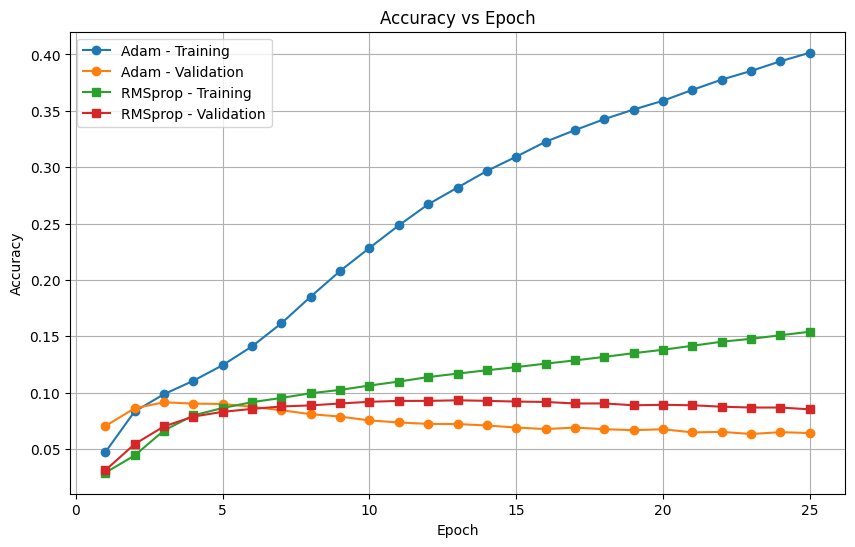

In [22]:
# ============================================================
# ACCURACY VS EPOCH
# ============================================================

epoch_range = range(1, epochs + 1)

plt.figure(figsize=(10, 6))

plt.plot(
    epoch_range,
    adam_train_accuracy,
    marker="o",
    label="Adam - Training"
)

plt.plot(
    epoch_range,
    adam_val_accuracy,
    marker="o",
    label="Adam - Validation"
)

plt.plot(
    epoch_range,
    rms_train_accuracy,
    marker="s",
    label="RMSprop - Training"
)

plt.plot(
    epoch_range,
    rms_val_accuracy,
    marker="s",
    label="RMSprop - Validation"
)

plt.title("Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

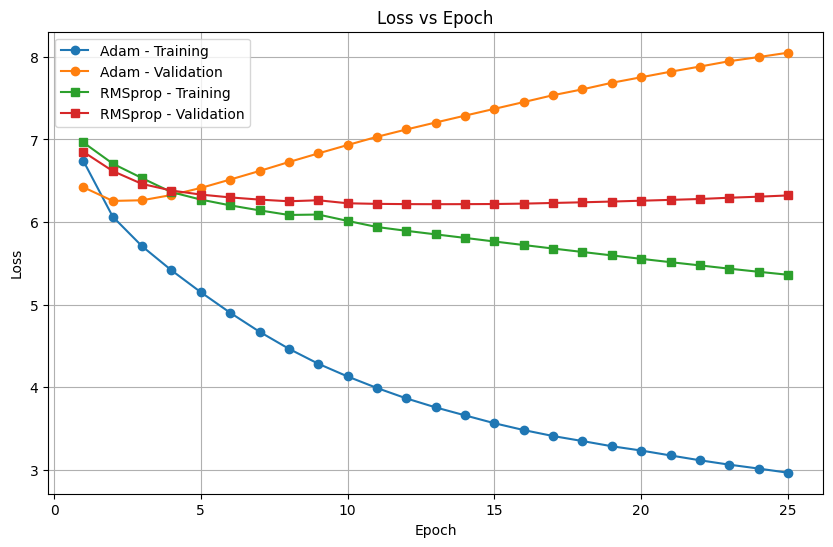

In [23]:
# ============================================================
# LOSS VS EPOCH
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    epoch_range,
    adam_train_loss,
    marker="o",
    label="Adam - Training"
)

plt.plot(
    epoch_range,
    adam_val_loss,
    marker="o",
    label="Adam - Validation"
)

plt.plot(
    epoch_range,
    rms_train_loss,
    marker="s",
    label="RMSprop - Training"
)

plt.plot(
    epoch_range,
    rms_val_loss,
    marker="s",
    label="RMSprop - Validation"
)

plt.title("Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

In [24]:
# ============================================================
# OPTIMIZER COMPARISON
# ============================================================

print("============================================================")
print("OPTIMIZER COMPARISON")
print("============================================================")

print("\n{:<12} {:<18} {:<18} {:<18} {:<18}".format(
    "Optimizer",
    "Train Accuracy",
    "Val Accuracy",
    "Train Loss",
    "Val Loss"
))

print("-" * 90)

print("{:<12} {:<18.4f} {:<18.4f} {:<18.4f} {:<18.4f}".format(
    "Adam",
    adam_train_accuracy[-1],
    adam_val_accuracy[-1],
    adam_train_loss[-1],
    adam_val_loss[-1]
))

print("{:<12} {:<18.4f} {:<18.4f} {:<18.4f} {:<18.4f}".format(
    "RMSprop",
    rms_train_accuracy[-1],
    rms_val_accuracy[-1],
    rms_train_loss[-1],
    rms_val_loss[-1]
))

OPTIMIZER COMPARISON

Optimizer    Train Accuracy     Val Accuracy       Train Loss         Val Loss          
------------------------------------------------------------------------------------------
Adam         0.4015             0.0641             2.9655             8.0498            
RMSprop      0.1540             0.0852             5.3618             6.3222            


In [25]:
# ============================================================
# SELECT MODEL FOR TEXT GENERATION
# ============================================================

if adam_val_accuracy[-1] >= rms_val_accuracy[-1]:
    best_model = adam_model
    best_optimizer = "Adam"
else:
    best_model = rmsprop_model
    best_optimizer = "RMSprop"

print("============================================================")
print("BEST MODEL")
print("============================================================")

print("Selected optimizer:", best_optimizer)

BEST MODEL
Selected optimizer: RMSprop


In [26]:
# ============================================================
# CREATE REVERSE WORD INDEX
# ============================================================

reverse_word_index = {
    index: word
    for word, index in tokenizer.word_index.items()
}

print("Reverse vocabulary created successfully.")

Reverse vocabulary created successfully.


In [27]:
# ============================================================
# TEXT GENERATION FUNCTION
# ============================================================

def generate_text(seed_text, next_words=30):

    generated_text = seed_text.lower()

    for _ in range(next_words):

        # Convert text into token IDs
        token_list = tokenizer.texts_to_sequences(
            [generated_text]
        )[0]

        # Keep only the last 10 words
        token_list = token_list[-sequence_length:]

        # Pad the sequence
        token_list = pad_sequences(
            [token_list],
            maxlen=sequence_length,
            padding="pre"
        )

        # Predict next word probabilities
        predictions = best_model.predict(
            token_list,
            verbose=0
        )[0]

        # Get word ID with highest probability
        predicted_id = np.argmax(predictions)

        # Convert ID back to word
        predicted_word = reverse_word_index.get(
            predicted_id,
            None
        )

        if predicted_word is None:
            break

        # Add predicted word
        generated_text += " " + predicted_word

    return generated_text

In [28]:
# ============================================================
# TEXT GENERATION - SAMPLE 1
# ============================================================

seed = "the king"

generated_text = generate_text(
    seed,
    next_words=30
)

print("============================================================")
print("GENERATED TEXT")
print("Student Roll No: 24BAD057")
print("============================================================")

print("\nSeed:")
print(seed)

print("\nGenerated Text:")
print(generated_text)

GENERATED TEXT
Student Roll No: 24BAD057

Seed:
the king

Generated Text:
the king and let him be the king and let him be the duke of york i am a king to the king and let him be the king and let him


In [29]:
# ============================================================
# MULTIPLE TEXT GENERATION SAMPLES
# ============================================================

seeds = [
    "the king",
    "my lord",
    "thou art",
    "i will",
    "the world"
]

print("============================================================")
print("MULTIPLE GENERATED TEXT SAMPLES")
print("Student Roll No: 24BAD057")
print("============================================================")

for i, seed in enumerate(seeds, start=1):

    generated = generate_text(
        seed,
        next_words=30
    )

    print("\n")
    print("=" * 70)
    print("SAMPLE", i)
    print("Seed:", seed)
    print("-" * 70)
    print(generated)

MULTIPLE GENERATED TEXT SAMPLES
Student Roll No: 24BAD057


SAMPLE 1
Seed: the king
----------------------------------------------------------------------
the king and let him be the king and let him be the duke of york i am a king to the king and let him be the king and let him


SAMPLE 2
Seed: my lord
----------------------------------------------------------------------
my lord i am a king to the king and let him be the king and let him be the duke of york i am a king to the king and let


SAMPLE 3
Seed: thou art
----------------------------------------------------------------------
thou art a king to thy heart and that thou art a king to thy heart and that thou art a king to thy heart and that thou art a king to


SAMPLE 4
Seed: i will
----------------------------------------------------------------------
i will not what i am a king to the king and let him be the king and let him be the duke of york i am a king to the king


SAMPLE 5
Seed: the world
--------------------------------

In [30]:
# ============================================================
# SAVE GENERATED TEXT
# ============================================================

with open(
    "generated_text_24BAD057.txt",
    "w",
    encoding="utf-8"
) as file:

    file.write(
        "RNN TEXT GENERATION - TINY SHAKESPEARE\n"
    )

    file.write(
        "Student Roll No: 24BAD057\n"
    )

    file.write(
        f"Selected Optimizer: {best_optimizer}\n\n"
    )

    for i, seed in enumerate(seeds, start=1):

        generated = generate_text(
            seed,
            next_words=30
        )

        file.write(f"Sample {i}\n")
        file.write(f"Seed: {seed}\n")
        file.write(
            f"Generated Text: {generated}\n"
        )

        file.write("\n" + "=" * 70 + "\n")

print("Generated text saved successfully.")

Generated text saved successfully.


In [31]:
# ============================================================
# SAVE TRAINED MODEL
# ============================================================

best_model.save(
    "tiny_shakespeare_rnn_24BAD057.keras"
)

print("Model saved successfully.")
print("Filename: tiny_shakespeare_rnn_24BAD057.keras")

Model saved successfully.
Filename: tiny_shakespeare_rnn_24BAD057.keras
